In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
df = pd.read_csv("messy_clustering_1500.csv")
df

,Customer_ID,Annual_Spend_k,Purchase_Frequency,Avg_Order_Value,Website_Visits,Preferred_Channel
0,20001,19.80,34.98,19.44,5.34,Web
1,20002,25.53,NaN,33.59,9.62,Web
2,20003,16.22,37.73,19.58,7.10,Store
3,20004,27.88,24.18,26.72,12.02,web
4,20005,19.49,29.80,28.46,6.16,Mobile App
...,...,...,...,...,...,...
1495,21496,89.98,52.97,77.06,2.88,App
1496,21497,95.87,38.56,69.87,16.67,Store
1497,21498,100.06,39.22,69.13,8.84,Store
1498,21499,93.77,46.28,78.63,7.02,Mobile App


In [4]:
df.shape

(1500, 6)

In [5]:
df.describe()

,Customer_ID,Annual_Spend_k,Purchase_Frequency,Avg_Order_Value,Website_Visits
count,1500.000000,1464.000000,1463.000000,1463.000000,1464.000000
mean,20750.500000,60.223456,49.593042,55.925687,8.606127
std,433.157015,33.236118,24.079326,23.856891,10.078134
min,20001.000000,11.610000,9.190000,2.500000,1.220000
25%,20375.750000,27.582500,31.340000,31.060000,5.240000
50%,20750.500000,60.380000,41.780000,63.770000,7.210000
75%,21125.250000,89.365000,68.600000,75.720000,9.970000
max,21500.000000,343.190000,211.990000,102.210000,159.010000


In [6]:
print(df["Preferred_Channel"].value_counts())

Preferred_Channel
Web           458
Store         374
App           305
STORE         127
web           119
Mobile App    117
Name: count, dtype: int64


In [7]:
X = df.drop(columns=["Customer_ID"])

In [8]:
num_cols = [
    "Annual_Spend_k",
    "Purchase_Frequency",
    "Avg_Order_Value",
    "Website_Visits"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [9]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df[num_cols].isnull().sum()

Annual_Spend_k        0
Purchase_Frequency    0
Avg_Order_Value       0
Website_Visits        0
dtype: int64

In [10]:
df["Preferred_Channel"] = (
    df["Preferred_Channel"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["Preferred_Channel"] = df["Preferred_Channel"].replace({
    "app": "mobile app",
    "mobile app": "mobile app"
})

print(df["Preferred_Channel"].value_counts())

Preferred_Channel
web           577
store         501
mobile app    422
Name: count, dtype: int64


In [11]:
for col in num_cols:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df[col] = df[col].clip(lower_bound, upper_bound)

In [21]:
# 1. Fill missing numerical values in X
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

# 2. Check missing values
print(X.isnull().sum())

Annual_Spend_k        0
Purchase_Frequency    0
Avg_Order_Value       0
Website_Visits        0
Preferred_Channel     0
dtype: int64


In [22]:

cat_cols = ["Preferred_Channel"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(sparse_output=False), cat_cols)
    ]
)

X_scaled = preprocessor.fit_transform(X)

print("Shape after preprocessing:", X_scaled.shape)

Shape after preprocessing: (1500, 10)


C:\Users\Saswa\.conda\envs\eda_env1\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Saswa\.conda\envs\eda_env1\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Saswa\.conda\envs\eda_env1\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Saswa\.conda\envs\eda_env1\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMe

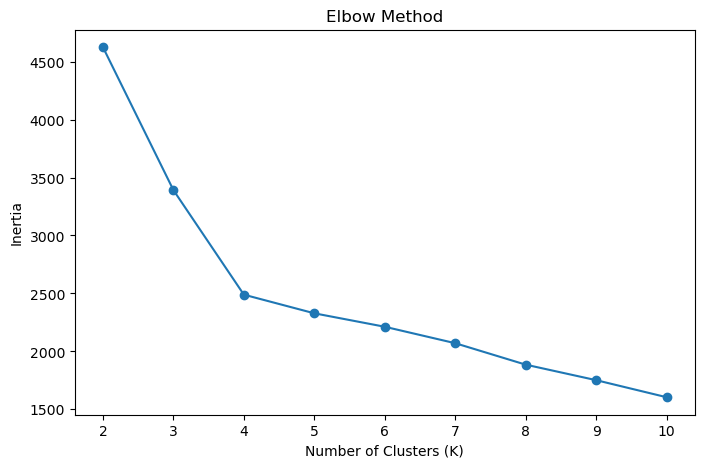

In [23]:
#eloww m

inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10 #for 10 random centroid initializations , we find the point with lowest inertia
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(K_range)
plt.show()

In [14]:
import numpy as np

print("NaN values in X_scaled:", np.isnan(X_scaled).sum())

NaN values in X_scaled: 146


In [15]:
print("Original X shape:", X.shape)
print("Processed X shape:", X_scaled.shape)
print("NaNs in X_scaled:", np.isnan(X_scaled).sum())

Original X shape: (1500, 5)
Processed X shape: (1500, 10)
NaNs in X_scaled: 146


In [16]:
nan_rows, nan_cols = np.where(np.isnan(X_scaled))

print("First 10 NaN positions:")
print(list(zip(nan_rows[:10], nan_cols[:10])))

First 10 NaN positions:
[(np.int64(1), np.int64(1)), (np.int64(15), np.int64(3)), (np.int64(26), np.int64(2)), (np.int64(32), np.int64(1)), (np.int64(35), np.int64(3)), (np.int64(41), np.int64(2)), (np.int64(52), np.int64(3)), (np.int64(54), np.int64(2)), (np.int64(62), np.int64(2)), (np.int64(80), np.int64(1))]


In [17]:
print("NaNs in original X:")
print(X.isnull().sum())

print("\nNaNs in numerical columns:")
print(X[num_cols].isnull().sum())

print("\nData types:")
print(X.dtypes)

NaNs in original X:
Annual_Spend_k        36
Purchase_Frequency    37
Avg_Order_Value       37
Website_Visits        36
Preferred_Channel      0
dtype: int64

NaNs in numerical columns:
Annual_Spend_k        36
Purchase_Frequency    37
Avg_Order_Value       37
Website_Visits        36
dtype: int64

Data types:
Annual_Spend_k        float64
Purchase_Frequency    float64
Avg_Order_Value       float64
Website_Visits        float64
Preferred_Channel      object
dtype: object


In [19]:
X_scaled = preprocessor.fit_transform(X)

print("NaNs in X_scaled:", np.isnan(X_scaled).sum())

NaNs in X_scaled: 146


In [20]:
# Check missing values in the data BEFORE preprocessing
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in numerical columns:")
print(X[num_cols].isnull().sum())

print("\nData types:")
print(X.dtypes)

Missing values in X:
Annual_Spend_k        36
Purchase_Frequency    37
Avg_Order_Value       37
Website_Visits        36
Preferred_Channel      0
dtype: int64

Missing values in numerical columns:
Annual_Spend_k        36
Purchase_Frequency    37
Avg_Order_Value       37
Website_Visits        36
dtype: int64

Data types:
Annual_Spend_k        float64
Purchase_Frequency    float64
Avg_Order_Value       float64
Website_Visits        float64
Preferred_Channel      object
dtype: object


In [24]:
# ==========================================
# 11. TRAIN FINAL K-MEANS
# ==========================================

best_k = 4

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

# Train the model and assign cluster labels
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means training completed.")

K-Means training completed.


C:\Users\Saswa\.conda\envs\eda_env1\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [25]:


cluster_counts = df["Cluster"].value_counts().sort_index()

print("Number of customers in each cluster:")
print(cluster_counts)

Number of customers in each cluster:
Cluster
0    479
1    493
2    519
3      9
Name: count, dtype: int64


In [26]:
# ==========================================
# 14. CATEGORICAL ANALYSIS
# ==========================================

channel_analysis = pd.crosstab(
    df["Cluster"],
    df["Preferred_Channel"],
    normalize="index"
) * 100

print("Preferred channel distribution (%):")
print(channel_analysis.round(2))

Preferred channel distribution (%):
Preferred_Channel  mobile app  store    web
Cluster                                    
0                       27.35  32.78  39.87
1                       30.43  32.25  37.32
2                       26.40  35.07  38.54
3                       44.44  33.33  22.22


In [27]:
# ==========================================
# 15. CLUSTER CENTERS
# ==========================================

cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=preprocessor.get_feature_names_out()
)

print("Cluster Centers:")
print(cluster_centers.round(2))

Cluster Centers:
   num__Annual_Spend_k  num__Purchase_Frequency  num__Avg_Order_Value  \
0                 0.02                     1.22                  0.46   
1                 1.07                    -0.35                  0.82   
2                -1.05                    -0.79                 -1.21   
3                 0.38                    -0.22                  0.26   

   num__Website_Visits  cat__Preferred_Channel_App  \
0                 0.01                        0.20   
1                -0.10                        0.23   
2                -0.12                        0.18   
3                11.72                        0.33   

   cat__Preferred_Channel_Mobile App  cat__Preferred_Channel_STORE  \
0                               0.08                          0.09   
1                               0.07                          0.09   
2                               0.09                          0.08   
3                               0.11                          0.00

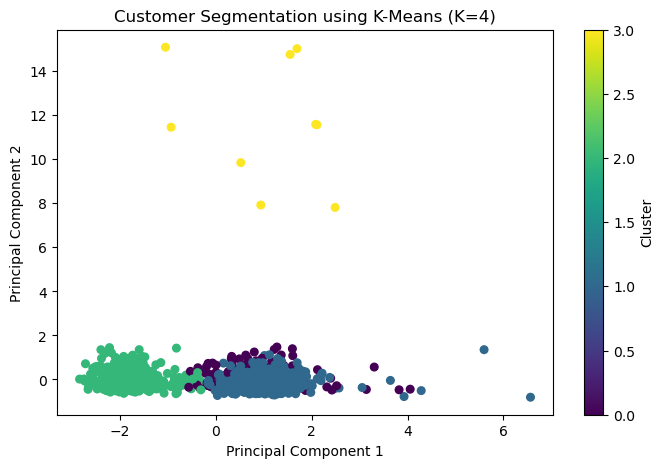

In [28]:
from sklearn.decomposition import PCA

# Reduce the scaled features to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["Cluster"],
    cmap="viridis",
    s=30
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means (K=4)")
plt.colorbar(label="Cluster")
plt.show()